# Chapter 7 — Coordination: The Simple Model
**Modeling Social Behavior** | Smaldino

---

## 📚 What This Chapter Is About

**Coordination problems** arise when the best action for any individual depends on what other people are doing. Unlike cooperation problems (where you might be tempted to defect), coordination problems don't have a conflict of interest. Everyone *wants* to coordinate. The challenge is just landing on the *same* convention.

Classic real-world examples:
- Driving on the left vs. right side of the road
- Choosing a file format (PDF vs. Word)
- Language and vocabulary
- Social norms around greetings, dress codes, etc.

---

## 🧠 Core Concepts You Need

### 1. Two-Norm Coordination Game

There are **two norms** in the population: Norm 1 and Norm 2. Neither is intrinsically better than the other. What matters is **how many others use the same norm as you**.

- If most people use Norm 1, Norm 1 holders do better.
- If most people use Norm 2, Norm 2 holders do better.
- This is a **positive feedback loop**: whichever norm is more common gets an advantage, which makes it *more* common, and so on.

This means the system has **two stable equilibria**: all-Norm-1 or all-Norm-2. Which one the population reaches depends almost entirely on **initial frequencies**.

### 2. Payoff Structure

Every agent gets a **baseline payoff of 1**, plus a **coordination bonus** that scales with how many others share their norm:

$$\pi_1 = 1 + p_1 \cdot b$$
$$\pi_2 = 1 + (1 - p_1) \cdot b$$

Where:
- $p_1$ = frequency of Norm 1 in the population (a number between 0 and 1)
- $b$ = `coordination_benefit` — a slider parameter controlling how much coordination matters
- $\pi_1$, $\pi_2$ = payoffs for Norm 1 and Norm 2 holders respectively

Note: payoffs are **population-level**, not pairwise. Every Norm 1 agent has the same payoff.

### 3. Success-Biased Imitation (Fermi Rule)

Agents don't switch norms randomly. They **observe one random other agent** and copy them probabilistically — with higher probability if that agent has a higher payoff than themselves.

The probability of copying is given by the **Fermi function** (also called a logistic/sigmoid function):

$$P(\text{copy}) = \frac{1}{1 + e^{-(\pi_{\text{other}} - \pi_{\text{self}})}}$$

Key properties:
- If `other_payoff == self_payoff` → P(copy) = 0.5 (coin flip)
- If `other_payoff > self_payoff` → P(copy) > 0.5 (lean toward copying)
- If `other_payoff < self_payoff` → P(copy) < 0.5 (lean against copying)
- Agents **only consider copying if the other agent has a different norm** — you can't copy what you already have.

This is called **success-biased imitation**: you're more likely to adopt the behavior of someone who is doing better than you.

### 4. Key Emergent Result

The simulation always converges to **one norm taking over completely** (fixation). Which norm wins is **stochastic** (random), but strongly influenced by initial frequency. If Norm 1 starts above 50%, it's more likely to win — and this effect gets stronger with more agents and higher coordination benefits.

---

## 🔢 Variable Reference

| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_norm1` | Global (parameter) | Initial fraction of agents with Norm 1 (0–1) |
| `coordination_benefit` | Global (parameter) | Bonus multiplier for coordinating with others |
| `agents` | Global | List of all Agent objects |
| `agent.norm` | Agent | Integer: 1 = Norm 1, 2 = Norm 2 |
| `agent.payoff` | Agent | Float: agent's current payoff |
| `p1` | Local (inside functions) | Frequency of Norm 1 in the current tick |
| `history` | Global | List tracking freq of Norm 1 over time |

---

## 📦 Imports

In [1]:
# Standard scientific Python stack
import numpy as np                        # numerical operations
import matplotlib.pyplot as plt           # plotting
import matplotlib.gridspec as gridspec    # for subplot layouts
from matplotlib.patches import Patch      # for custom legend entries
import random                             # random sampling
from copy import deepcopy                 # not used here but good practice to import

# Make plots look clean
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## 🤖 Agent Class

Each agent has two **agent-level attributes**:
- `norm`: which norm they currently hold (1 or 2)
- `payoff`: their payoff at the current tick (updated each step)

In [2]:
class Agent:
    """
    Represents one individual in the coordination model.

    Agent-level attributes:
    -----------------------
    norm   : int   — which norm the agent currently holds (1 or 2)
    payoff : float — the agent's payoff this tick, calculated from population frequency
    """

    def __init__(self, norm):
        # Agent attribute: which norm does this agent hold?
        # Set at initialization, can change via imitation
        self.norm = norm  # int: 1 or 2

        # Agent attribute: payoff, initialized to 0
        # Will be overwritten each tick in calculate_payoffs()
        self.payoff = 0.0  # float

---
## ⚙️ Model Functions

The model is organized into three functions mirroring the original code's structure:
1. `setup()` — create and initialize all agents
2. `calculate_payoffs()` — compute each agent's payoff based on population norm frequency
3. `evolve()` — agents look at one random other and possibly copy their norm
4. `run()` — the main loop tying everything together

In [3]:
def setup(N, init_norm1):
    """
    Create the population of agents and randomly assign norms.

    Parameters (Global-level parameters passed in):
    ------------------------------------------------
    N          : int   — total number of agents in the population
    init_norm1 : float — probability that any given agent starts with Norm 1 (0 to 1)

    Returns:
    --------
    agents : list of Agent objects — the initialized population
    """

    agents = []  # local variable: will become the global agent list

    for i in range(N):
        # Assign Norm 1 with probability init_norm1, else Norm 2
        # random.random() draws a uniform float in [0, 1)
        if random.random() < init_norm1:
            norm = 1
        else:
            norm = 2

        # Create a new Agent with the assigned norm and add to population
        agents.append(Agent(norm))

    return agents


def calculate_payoffs(agents, coordination_benefit):
    """
    Compute the payoff for every agent this tick.

    Payoffs are POPULATION-LEVEL: every Norm 1 agent gets the same payoff,
    and every Norm 2 agent gets the same payoff. This is because we assume
    agents interact with the whole population (mean-field assumption).

    Payoff formula:
        Norm 1 payoff = 1 + p1 * coordination_benefit
        Norm 2 payoff = 1 + (1 - p1) * coordination_benefit

    Parameters:
    -----------
    agents               : list of Agent — the full population
    coordination_benefit : float — how much extra payoff you get for coordinating

    Modifies agents in place (sets agent.payoff for each agent).
    """

    N = len(agents)  # local: total agent count

    # Local variable: frequency of Norm 1 in the current population
    # This is the key quantity — it determines everyone's payoff
    p1 = sum(1 for a in agents if a.norm == 1) / N

    # Local variables: compute payoffs for each norm group
    # Norm 1 does better when p1 is high (many others share your norm)
    norm1_payoff = 1 + p1 * coordination_benefit

    # Norm 2 does better when p1 is low (i.e., many people use Norm 2)
    norm2_payoff = 1 + (1 - p1) * coordination_benefit

    # Assign payoffs to each agent based on which norm they hold
    for agent in agents:
        if agent.norm == 1:
            agent.payoff = norm1_payoff
        else:
            agent.payoff = norm2_payoff


def fermi(payoff_other, payoff_self):
    """
    The Fermi (logistic/sigmoid) function for success-biased imitation.

    Returns the probability that an agent copies another agent's norm,
    given the difference in their payoffs.

    Formula:
        P(copy) = 1 / (1 + exp(-(payoff_other - payoff_self)))

    When payoff_other > payoff_self: P > 0.5  (likely to copy)
    When payoff_other < payoff_self: P < 0.5  (unlikely to copy)
    When payoff_other == payoff_self: P = 0.5 (coin flip)

    Parameters:
    -----------
    payoff_other : float — the payoff of the agent being observed
    payoff_self  : float — the focal agent's own payoff

    Returns:
    --------
    float in (0, 1) — probability of copying
    """
    return 1.0 / (1.0 + np.exp(-(payoff_other - payoff_self)))


def evolve(agents):
    """
    One full round of success-biased imitation.

    Each agent:
    1. Picks one other agent at random.
    2. If that agent has a DIFFERENT norm, computes the probability of copying
       using the Fermi function.
    3. With that probability, adopts the other agent's norm.

    Important: agents are updated using a RANDOMLY SHUFFLED order,
    which avoids order-of-update artifacts.

    Parameters:
    -----------
    agents : list of Agent — the full population

    Modifies agents in place (may change agent.norm for some agents).
    """

    # Shuffle update order to avoid systematic bias
    # (In NetLogo, 'ask turtles' also randomizes the order)
    shuffled = agents[:]          # local: copy of the list (not the agents themselves)
    random.shuffle(shuffled)

    for agent in shuffled:
        # Pick one random OTHER agent as a potential model
        # local variable: the agent being observed
        model = random.choice(agents)

        # Only consider copying if the model has a DIFFERENT norm
        # (copying your own norm would do nothing)
        if model.norm != agent.norm:

            # local variable: probability of switching to the model's norm
            prob_copy = fermi(model.payoff, agent.payoff)

            # With probability prob_copy, adopt the model's norm
            if random.random() < prob_copy:
                agent.norm = model.norm


def run(N, init_norm1, coordination_benefit, max_ticks=2000):
    """
    Run the full simulation and return a history of Norm 1 frequency.

    Global parameters:
    ------------------
    N                    : int   — population size
    init_norm1           : float — initial frequency of Norm 1 (0 to 1)
    coordination_benefit : float — payoff bonus for coordinating
    max_ticks            : int   — maximum number of time steps before stopping

    Returns:
    --------
    history : list of float — frequency of Norm 1 at each tick
    """

    # Initialize the population
    agents = setup(N, init_norm1)

    # Global tracking: record norm frequencies over time
    history = []

    for tick in range(max_ticks):

        # Local variable: count of Norm 1 holders this tick
        n_norm1 = sum(1 for a in agents if a.norm == 1)

        # Record the current frequency of Norm 1
        freq_norm1 = n_norm1 / N
        history.append(freq_norm1)

        # STOPPING CONDITION: if one norm has taken over completely, stop
        # (This mirrors the NetLogo 'stop' condition)
        if n_norm1 == 0 or n_norm1 == N:
            break

        # Step 1: calculate payoffs based on current norm frequencies
        calculate_payoffs(agents, coordination_benefit)

        # Step 2: agents observe others and potentially switch norms
        evolve(agents)

    return history

---
## 🔬 Experiment 1: Single Run Visualization

Run the model once and plot how Norm 1's frequency changes over time.
This mirrors the NetLogo "Norms" plot panel.

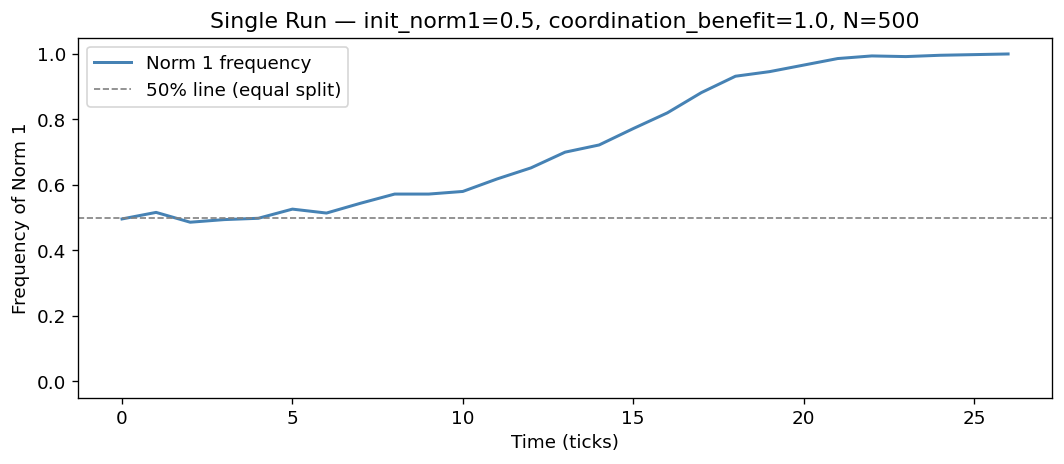

Simulation ended at tick 27 | Final freq Norm 1: 1.000 | Winner: Norm 1


In [4]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                    = 500    # population size (number of agents)
init_norm1           = 0.5    # 50% start with Norm 1, 50% with Norm 2
coordination_benefit = 1.0    # coordination bonus (called 'b' in the equations)
max_ticks            = 2000   # upper limit on simulation length
# ───────────────────────────────────────────────────────────────────────────────

random.seed(42)  # set random seed for reproducibility

# Run a single simulation
history = run(N, init_norm1, coordination_benefit, max_ticks)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(history, color='steelblue', linewidth=1.8, label='Norm 1 frequency')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% line (equal split)')
ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1')
ax.set_title(f'Single Run — init_norm1={init_norm1}, coordination_benefit={coordination_benefit}, N={N}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

# Print what happened
winner = 'Norm 1' if history[-1] == 1.0 else ('Norm 2' if history[-1] == 0.0 else 'Neither (still running)')
print(f"Simulation ended at tick {len(history)} | Final freq Norm 1: {history[-1]:.3f} | Winner: {winner}")

---
## 🔬 Experiment 2: Multiple Runs — Stochasticity of Outcomes

Run the model many times from the same starting conditions.

**Key question:** With a 50/50 starting split, which norm wins — and why?

This illustrates that coordination models with equal initial frequencies lead to **random fixation** — like genetic drift in evolutionary biology. Small random fluctuations early on can tip the whole system one way.

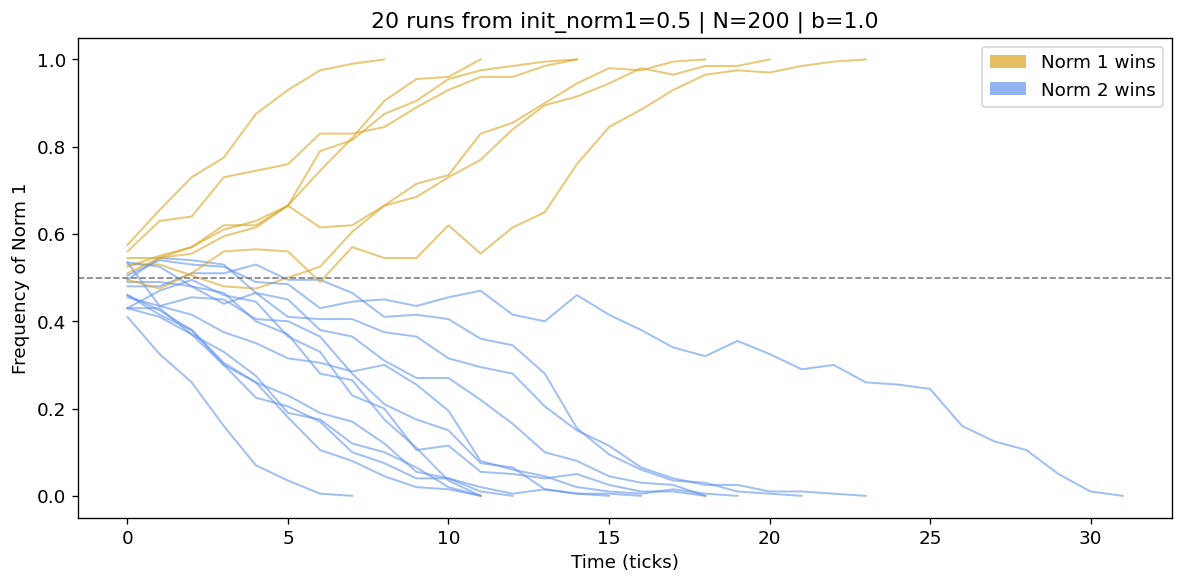

Norm 1 won: 7/20 runs (35%)
Norm 2 won: 13/20 runs (65%)


In [5]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                    = 200    # smaller population = faster runs and more visible drift
init_norm1           = 0.5    # perfectly balanced starting point
coordination_benefit = 1.0
max_ticks            = 3000
n_runs               = 20     # number of independent simulation runs
# ───────────────────────────────────────────────────────────────────────────────

all_histories = []
winners = []  # track which norm won each run

for run_i in range(n_runs):
    h = run(N, init_norm1, coordination_benefit, max_ticks)
    all_histories.append(h)
    winners.append(h[-1])  # final frequency of Norm 1 (1.0 = Norm 1 won, 0.0 = Norm 2 won)

# ── Plot all trajectories ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for i, h in enumerate(all_histories):
    # Color-code by which norm won: gold = Norm 1, cornflowerblue = Norm 2
    color = 'goldenrod' if h[-1] == 1.0 else 'cornflowerblue'
    ax.plot(h, color=color, alpha=0.6, linewidth=1.2)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1')
ax.set_title(f'{n_runs} runs from init_norm1={init_norm1} | N={N} | b={coordination_benefit}')
ax.set_ylim(-0.05, 1.05)

# Legend
legend_elements = [
    Patch(facecolor='goldenrod', alpha=0.7, label='Norm 1 wins'),
    Patch(facecolor='cornflowerblue', alpha=0.7, label='Norm 2 wins')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

n_norm1_wins = sum(1 for w in winners if w == 1.0)
print(f"Norm 1 won: {n_norm1_wins}/{n_runs} runs ({100*n_norm1_wins/n_runs:.0f}%)")
print(f"Norm 2 won: {n_runs - n_norm1_wins}/{n_runs} runs ({100*(n_runs - n_norm1_wins)/n_runs:.0f}%)")

---
## 🔬 Experiment 3: Initial Frequency → Probability of Norm 1 Winning

This is the key experiment from the chapter. We sweep `init_norm1` from 0.3 to 0.7 and run many simulations at each value. We then plot the **probability that Norm 1 wins** as a function of its starting frequency.

**Expected result:** The win probability should be close to the initial frequency — a hallmark of **neutral drift** / stochastic dominance. But the relationship is steeper than a straight line: small advantages early get amplified by positive feedback.

In [6]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                    = 200
coordination_benefit = 1.0
max_ticks            = 5000
n_reps               = 100   # number of repetitions per init_norm1 value

# Range of initial Norm 1 frequencies to test
init_values = np.arange(0.30, 0.71, 0.02)  # 0.30, 0.32, ..., 0.70
# ───────────────────────────────────────────────────────────────────────────────

# For each init_norm1 value, record the fraction of runs where Norm 1 wins
win_probs = []  # global result: one probability per init_norm1 value

for init_val in init_values:
    wins = 0  # local counter: how many runs did Norm 1 win?

    for _ in range(n_reps):
        h = run(N, init_val, coordination_benefit, max_ticks)
        if h[-1] == 1.0:   # Norm 1 took over completely
            wins += 1

    win_probs.append(wins / n_reps)  # fraction of runs where Norm 1 won
    print(f"  init_norm1={init_val:.2f} | Norm 1 won {wins}/{n_reps} runs", flush=True)

print("\nDone!")

  init_norm1=0.30 | Norm 1 won 0/100 runs
  init_norm1=0.32 | Norm 1 won 0/100 runs
  init_norm1=0.34 | Norm 1 won 1/100 runs
  init_norm1=0.36 | Norm 1 won 0/100 runs
  init_norm1=0.38 | Norm 1 won 1/100 runs
  init_norm1=0.40 | Norm 1 won 6/100 runs
  init_norm1=0.42 | Norm 1 won 6/100 runs
  init_norm1=0.44 | Norm 1 won 16/100 runs
  init_norm1=0.46 | Norm 1 won 33/100 runs
  init_norm1=0.48 | Norm 1 won 30/100 runs
  init_norm1=0.50 | Norm 1 won 50/100 runs
  init_norm1=0.52 | Norm 1 won 64/100 runs
  init_norm1=0.54 | Norm 1 won 67/100 runs
  init_norm1=0.56 | Norm 1 won 85/100 runs
  init_norm1=0.58 | Norm 1 won 92/100 runs
  init_norm1=0.60 | Norm 1 won 93/100 runs
  init_norm1=0.62 | Norm 1 won 98/100 runs
  init_norm1=0.64 | Norm 1 won 100/100 runs
  init_norm1=0.66 | Norm 1 won 99/100 runs
  init_norm1=0.68 | Norm 1 won 100/100 runs
  init_norm1=0.70 | Norm 1 won 100/100 runs

Done!


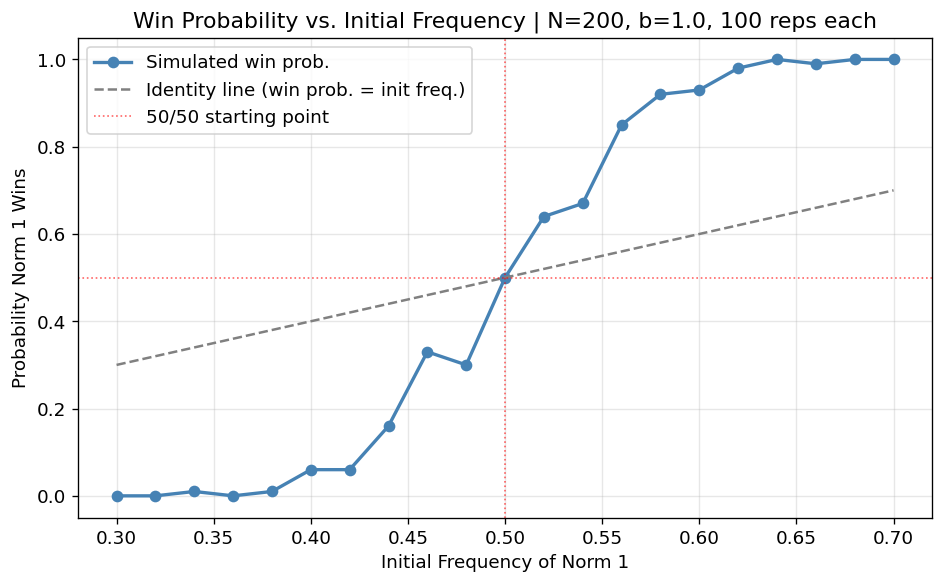

In [7]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(init_values, win_probs, 'o-', color='steelblue', linewidth=2, markersize=6, label='Simulated win prob.')

# Add diagonal reference line: if winning were purely proportional to initial frequency
ax.plot([0.3, 0.7], [0.3, 0.7], '--', color='gray', linewidth=1.5, label='Identity line (win prob. = init freq.)')

ax.axvline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.6, label='50/50 starting point')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.6)

ax.set_xlabel('Initial Frequency of Norm 1')
ax.set_ylabel('Probability Norm 1 Wins')
ax.set_title(f'Win Probability vs. Initial Frequency | N={N}, b={coordination_benefit}, {n_reps} reps each')
ax.set_xlim(0.28, 0.72)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 4: Effect of Coordination Benefit

What happens when we vary the coordination benefit `b`?

- **Low `b`**: payoffs are nearly equal regardless of norm → weak selection → outcomes are nearly random
- **High `b`**: large payoff differences → strong selection → initial majority advantage is amplified even more

We compare the win-probability curves for different values of `b`.

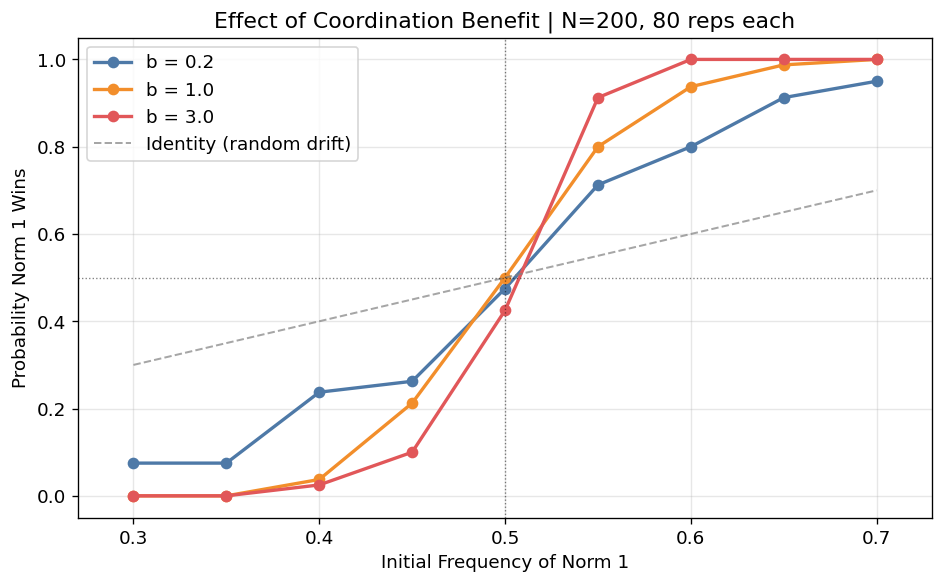

Done!


In [8]:
# ── Global parameters ──────────────────────────────────────────────────────────
N         = 200
max_ticks = 5000
n_reps    = 80
init_values = np.arange(0.30, 0.71, 0.05)  # coarser grid for speed

# Different values of coordination benefit to compare
benefit_values = [0.2, 1.0, 3.0]  # low / medium / high
colors         = ['#4e79a7', '#f28e2b', '#e15759']  # blue / orange / red
# ───────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

for benefit, color in zip(benefit_values, colors):
    win_probs_b = []  # local: win probabilities for this benefit value

    for init_val in init_values:
        wins = 0
        for _ in range(n_reps):
            h = run(N, init_val, benefit, max_ticks)
            if h[-1] == 1.0:
                wins += 1
        win_probs_b.append(wins / n_reps)

    ax.plot(init_values, win_probs_b, 'o-', color=color, linewidth=2,
            markersize=6, label=f'b = {benefit}')

# Reference lines
ax.plot([0.3, 0.7], [0.3, 0.7], '--', color='gray', linewidth=1.2, label='Identity (random drift)', alpha=0.7)
ax.axvline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Initial Frequency of Norm 1')
ax.set_ylabel('Probability Norm 1 Wins')
ax.set_title(f'Effect of Coordination Benefit | N={N}, {n_reps} reps each')
ax.set_xlim(0.27, 0.73)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Done!")

---
## 🔬 Experiment 5: Visualize the Fermi Function

The Fermi function is central to how imitation works in this model.
Let's visualize it directly to build intuition.

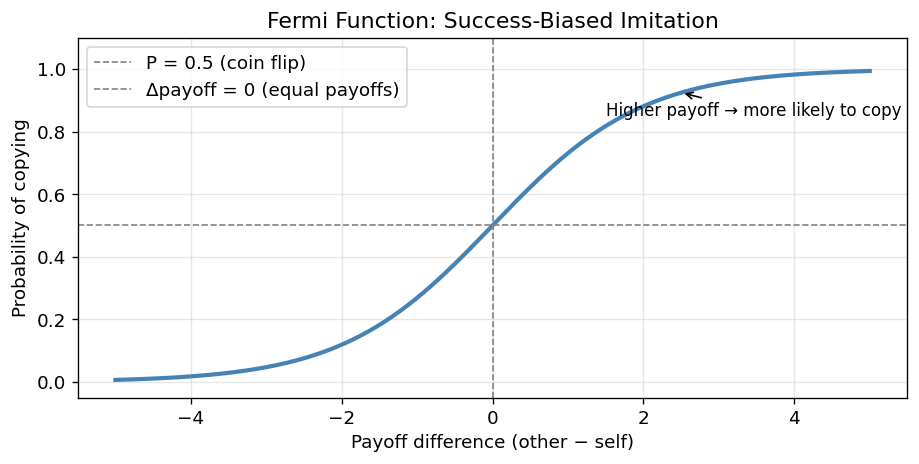

Fermi function examples:
  Δpayoff = -3  →  P(copy) = 0.047
  Δpayoff = -1  →  P(copy) = 0.269
  Δpayoff = +0  →  P(copy) = 0.500
  Δpayoff = +1  →  P(copy) = 0.731
  Δpayoff = +3  →  P(copy) = 0.953


In [9]:
# Local variable: range of payoff differences to visualize
delta = np.linspace(-5, 5, 200)  # other_payoff - self_payoff

# Apply the Fermi function across the range
p_copy = 1 / (1 + np.exp(-delta))

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(delta, p_copy, color='steelblue', linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='P = 0.5 (coin flip)')
ax.axvline(0.0, color='gray', linestyle='--', linewidth=1, label='Δpayoff = 0 (equal payoffs)')

# Annotate key points
ax.annotate('Higher payoff → more likely to copy',
            xy=(2.5, fermi(2.5, 0)), xytext=(1.5, 0.85),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Payoff difference (other − self)')
ax.set_ylabel('Probability of copying')
ax.set_title('Fermi Function: Success-Biased Imitation')
ax.set_ylim(-0.05, 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show a few example values
print("Fermi function examples:")
for d in [-3, -1, 0, 1, 3]:
    print(f"  Δpayoff = {d:+.0f}  →  P(copy) = {fermi(d, 0):.3f}")

---
## 🔬 Experiment 6: Population Size and Speed of Fixation

Larger populations take longer to reach fixation, but also show less variance across runs. This is the **population size - drift tradeoff** familiar from population genetics.

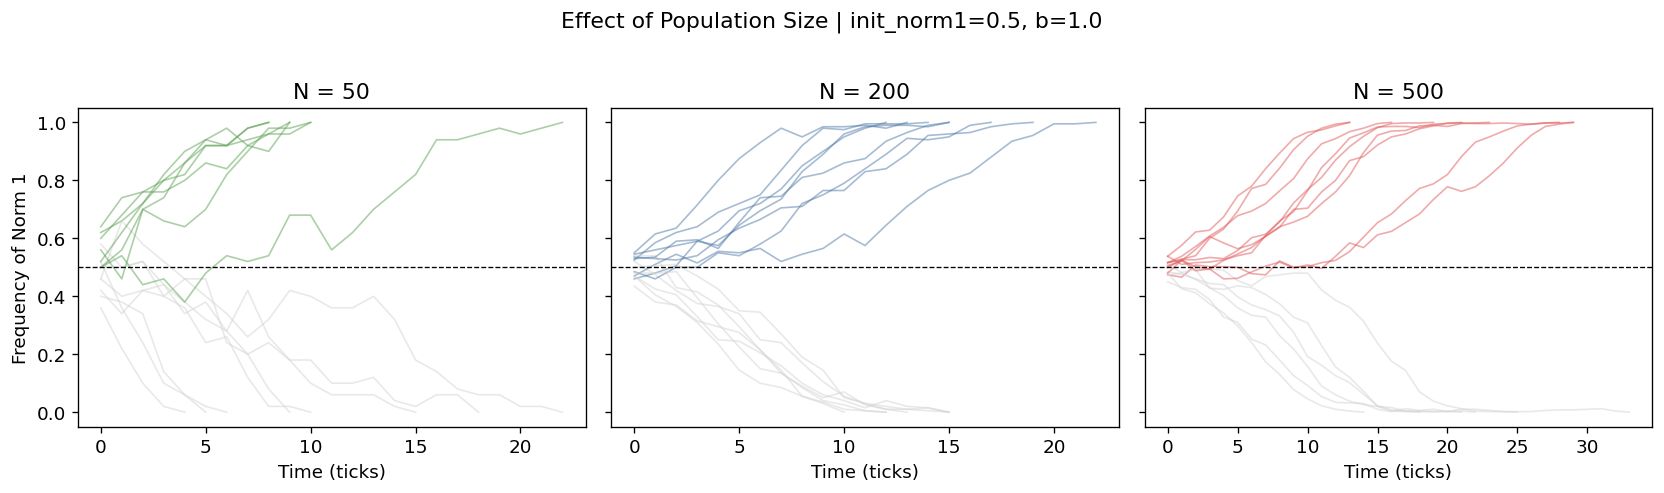

In [10]:
# ── Global parameters ──────────────────────────────────────────────────────────
init_norm1           = 0.5
coordination_benefit = 1.0
max_ticks            = 10000
n_reps               = 15       # runs per population size

population_sizes = [50, 200, 500]  # small / medium / large
colors = ['#59a14f', '#4e79a7', '#e15759']  # green / blue / red
# ───────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, N_val, color in zip(axes, population_sizes, colors):
    for _ in range(n_reps):
        h = run(N_val, init_norm1, coordination_benefit, max_ticks)
        c = color if h[-1] == 1.0 else 'lightgray'
        ax.plot(h, color=c, alpha=0.5, linewidth=1)

    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'N = {N_val}')
    ax.set_xlabel('Time (ticks)')
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('Frequency of Norm 1')
fig.suptitle(f'Effect of Population Size | init_norm1={init_norm1}, b={coordination_benefit}', y=1.02)
plt.tight_layout()
plt.show()

---

## 📝 Conceptual Summary

| Concept | What It Means In This Model |
|---|---|
| **Coordination problem** | Two valid norms; the best choice depends on what others do |
| **Positive feedback** | The more common norm gives higher payoffs → gets more common |
| **Two stable equilibria** | All-Norm-1 and All-Norm-2 are both absorbing states |
| **Unstable equilibrium** | A perfect 50/50 split is mathematically unstable; any tiny perturbation tips it |
| **Success-biased imitation** | Agents probabilistically copy others who do better (Fermi rule) |
| **Stochastic fixation** | With equal start: both norms have ~50% chance of winning |
| **Initial frequency matters** | Starting above 50% gives a strong advantage (amplified by selection) |
| **Coordination benefit b** | Higher `b` → stronger selection → initial advantages amplified faster |
| **Population size** | Larger N → slower drift → longer time to fixation |
